## Exercise: Hierarchical Models and Testing

### Eftychia Kazasi - 21/9/2026

Each of the 7 studies tested one question: "If you tell hotel guests that most other guests reuse their towels, does that make them more likely to reuse their own towel too?". In every study there are two groups of guests compared:
- Control group — got a normal "please help the environment" message
- Social norm group — got the "most guests reuse their towels" message



Our task: formulate and justify a parametric model for the intervention effect, estimate its parameters with Bayesian inference, and formally test whether the intervention has an effect, while accounting for between-study heterogeneity.

### Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.style as _mplstyle_pkg
from matplotlib.style import core as _mplstyle_core
_mplstyle_pkg.core = _mplstyle_core  
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt

### Load the dataset

In [ ]:
data = pd.read_csv("towelData.csv", sep=';', encoding='latin1') # make sure to put your path to the data

### Reshape the dataset

In [ ]:
count = data.iloc[:, -1] # get the last column with numbers of yes/no

# count has the number of yes and no for control and social norm groups for all the studies
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)]) # for every study the number of people in the control groups


social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)]) # for every study the number of people in the social norm groups


study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types, so it has the correct format for bambi 
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

print(combined_data)

    reuse  total    group study
0      74    211  control     1
1     103    277  control     2
2      77    135  control     3
3      82    187  control     4
4      21     25  control     5
5     123    147  control     6
6      28     30  control     7
7      98    222   social     1
8     587   1318   social     2
9     406    655   social     3
10    278    555   social     4
11     21     24   social     5
12    472    576   social     6
13    101    132   social     7


Each study reports counts of guests who did (Yes) or did not (No) reuse their towel, separately for the Control and Social Norm groups. We reshape this into one row per study-per-group, with the number of "successes" (towel reuse) and the total number of guests in that group, the format a binomial model expects.

We now have 14 rows (7 studies x 2 groups), each giving the number of guests who reused their towel (`reuse`) out of the total guests in that study-group (`total`). The data has been turned from short format to long format structure, that matches what `bambi` expects for a Binomial Generalized Linear Model, i.e. one row per binomial trial, with `reuse` as the number of successes and `total` as the number of trials.

### 1. Model formulation and justification

**Response distribution.** The outcome in each study-group is a count of successes out of a known number of trials (guests), so a **Binomial** family distribution for the response is an appropriate choice. 

**Accounting for between-study heterogeneity.** The 7 studies differ from each other, so we should not assume they share exactly the same baseline reuse rate. If we pooled all the data together and ignored this, the model would wrongly treat those study differences as random noise, which would make us overconfident in our results. To fix this, we give each study its own random intercept, while still letting the studies share information with each other (the 7 baseline rates aren't estimated in total isolation from each other, they're all assumed to come from one shared distribution).

**Model specification.** For study $s = 1,\ldots,7$ and group $g \in \{\text{control}, \text{social norm}\}$, let $y_{gs}$ be the number of guests who reused their towel, out of $n_{gs}$ total guests in that group. We model:

$$y_{gs} \sim \text{Binomial}(n_{gs}, p_{gs})$$

$$\text{logit}(p_{gs}) = \beta_0 + \beta_1 \cdot \text{Social}_{gs} + u_s$$

$$u_s \sim N(0, \tau^2), \quad s = 1,\ldots,7$$

where:
- $\beta_0$ is the (fixed) baseline log-odds of towel reuse in the control condition
- $\beta_1$ is the **fixed effect of interest**: the log-odds ratio for towel reuse under the social-norm intervention versus control, assumed constant across studies
- $u_s$ is a **random intercept per study**, capturing how much each study's baseline reuse rate differs from the others (different hotels, countries, guest populations)
- $\tau^2$ is the between-study variance, i.e. how much baseline reuse rates vary from study to study

We use a logit link because it maps the linear predictor onto the $(0,1)$ probability scale, which is the standard, appropriate choice for Binomial GLMs (Bambi's default for this family).

- We start with a random *intercept* only, i.e. with $u_s$ baseline rate varying from study to study (the intervention effect $\beta_1$ is fixed/shared across studies). 

**Hypothesis for testing.**

$$H_0: \beta_1 = 0 \quad \text{(no effect of the social-norm intervention)}$$
$$H_1: \beta_1 \neq 0 \quad \text{(the intervention changes towel-reuse probability)}$$

We will test this using the posterior distribution of $\beta_1$: reporting its posterior mean and 90% probability interval, and checking whether 0 is excluded from that interval, alongside the proportion of posterior mass with $\beta_1 > 0$ as a Bayesian p-value-style summary.

### 2. Method for estimation and its implementation

We fit the model using `bambi`, which builds the model with `PyMC` and samples from the posterior distribution every parameter ($\beta_0$, $\beta_1$, $\tau$, and each study's random intercept $u_s$), given the data and the priors, using the **NUTS** sampler (a type of MCMC — Markov Chain Monte Carlo — algorithm).

In [ ]:
# Specify the model

model = bmb.Model("p(reuse, total) ~ group + (1|study)", data=combined_data, family="binomial") # fit the model
print(model) # verify that the implementation is completed

       Formula: p(reuse, total) ~ group + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))


This confirms that the model bambi built matches what we specified in Section 1: a Binomial family with a logit link, a fixed effect for `group` (the intervention), and a random intercept per `study`. bambi's default weakly-informative priors are shown above (Normal priors on the fixed effects, a half-Normal prior on the between-study SD).

In [33]:
# Bayesian inference

fitted = model.fit(
    draws=2000, tune=2000, chains=4, cores=1,
    target_accept=0.98,   
    random_seed=42, progressbar=False
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 129 seconds.


### 3. Convergence diagnostics

Before trusting any posterior summary, we check that the sampler actually converged:
- R-hat should be close to 1.00 for every parameter (it compares the 4 independent chains and if they agree, R-hat ≈ 1).
- No divergences reported by the sampler (divergences signal the sampler struggled with the shape of the posterior).

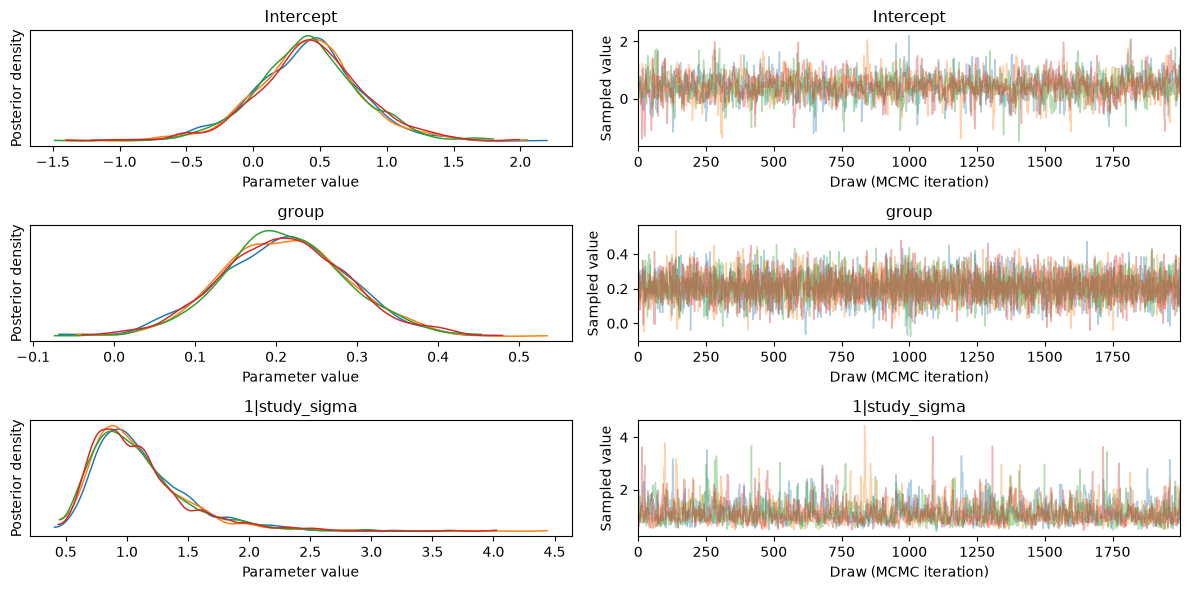

In [34]:
axes = az.plot_trace(fitted, var_names=["Intercept", "group", "1|study_sigma"], chain_prop="color")

for i in range(len(axes)):
    axes[i, 0].set_xlabel("Parameter value")
    axes[i, 0].set_ylabel("Posterior density")
    axes[i, 1].set_xlabel("Draw (MCMC iteration)")
    axes[i, 1].set_ylabel("Sampled value")

plt.tight_layout()
plt.show()

The plots on the left column are posterior density plots. The x-axis is the actual value the parameter could take and the y-axis is the posterior density. The plots on the right column are trace plots. The x-axis shows the draw number (which of the 2000 post-tuning MCMC iterations you're looking at) and the y-axis shows the sampled value of that parameter at that particular draw.

Convergence looks clean. In every row, the 4 colored density curves sit almost exactly on top of each other, and the 4 trace streaks occupy the same horizontal band throughout all 2000 draws with no chain drifting off on its own.

### 4. Parameter summary (posterior mean and 90% probability interval)

In [35]:
summary = az.summary(fitted, var_names=["Intercept", "group", "1|study_sigma"], hdi_prob=0.9)
summary

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.412,0.408,-0.227,1.083,0.010,0.008,1579.0,2239.0,1.0
group[social],0.210,0.077,0.080,0.334,0.001,0.001,4435.0,4112.0,1.0
1|study_sigma,1.101,0.405,0.535,1.642,0.010,0.011,1514.0,2254.0,1.0


| Parameter | Meaning | Posterior mean | 90% probability interval |
|---|---|---|---|
| $\beta_0$ (Intercept) | control group's baseline log-odds of towel reuse | 0.41 | (−0.23, 1.08) |
| $\beta_1$ (group[social]) | log-odds ratio for the social-norm intervention | 0.21 | (0.08, 0.33) |
| $\tau$ (study SD) | between-study heterogeneity in baseline reuse rate | 1.10 | (0.54, 1.64) |

$\tau$'s substantial size confirms the studies genuinely differ in baseline reuse rate, justifying the random-intercept structure chosen in Section 1.

-> Looking at the R-hat column in the summary table, every parameter has R-hat = 1.00. This, in addition with the fact that there is absence of any divergence signal in the plots of Section 3, confirm that the sampler converged properly.

### 5. Method for testing and reliability of the results

Recall the hypotheses formulated in Section 1:

$$H_0: \beta_1 = 0 \quad \text{vs.} \quad H_1: \beta_1 \neq 0$$

We test this in two ways using the posterior samples of $\beta_1$ produced by the MCMC fit in Section 2:

In [37]:
# Test 1: does the 90% probability interval for beta_1 exclude 0?
print(f"Test 1")
print(f"--------------------------------------------------------")
lower, upper = np.percentile(beta1_samples, [5, 95])
print(f"90% probability interval for beta_1: ({lower:.3f}, {upper:.3f})")
print(f"Excludes 0: {lower > 0 or upper < 0}")

print()

# Test 2: posterior probability that the effect is positive (Bayesian p-value style)
print(f"Test 2")
print(f"--------------------------------------------------------")
p_positive = (beta1_samples > 0).mean()
print(f"P(beta_1 > 0 | data) = {p_positive:.4f}")

Test 1
--------------------------------------------------------
90% probability interval for beta_1: (0.083, 0.339)
Excludes 0: True

Test 2
--------------------------------------------------------
P(beta_1 > 0 | data) = 0.9958


**Test 1** shows the 90% probability interval for $\beta_1$ is (0.083, 0.339), which does not contain 0, so we reject $H_0$ at the 90% level. **Test 2** independently supports this: 99.58% of the posterior mass for $\beta_1$ lies above 0. Together, these results give strong, consistent evidence that the social-norm intervention has a real, positive effect on towel-reuse behaviour, even after accounting for substantial heterogeneity between the 7 studies.

**Reliability of this result:** the decision of rejecting $H_0$ depends on two things, that make this conclusion reliable:
- (a) the sampler having converged cleanly (R-hat ≈ 1.00, no divergences) as confirmed in Section 3 and 4, meaning the posterior samples genuinely represent the posterior distribution rather than an unconverged approximation
- (b) the model's Binomial and random-intercept structure being an appropriate fit for grouped count data with between-study heterogeneity, as justified in Section 1. 

One limitation worth noting is that the model assumes that the intervention effect ($\beta_1$) is the same across all 7 studies and only the baseline reuse rate is allowed to vary by study. 